In [1]:
%matplotlib widget
# Boilerplate import code for all libraries
# Changes to the precision require re-loading the kernel and need to be done before any op uses them.
import sphWarpCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double

import sphWarpCore as sph
from sphWarpCore.type_config import *
print(get_type_config()) # confirms active settings

# Initialize warp at this point
import warp as wp; wp.init()

import os
import torch
if torch.cuda.is_available(): # set the TORCH_CUDA_ARCH_LIST environment variable to the compute capability of the GPU for faster compiles
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

# final import blocks that are generic
import matplotlib.pyplot as plt
from torch.profiler import profile, record_function, ProfilerActivity
import numpy as np
import math
import shlex    
import subprocess
import shutil

# custom SPH libraries
from integrators.integration import *
from sphWarpCore import *

# This library
from compressibleSPH import *

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:
import math
import numpy as np


nx = 128
dim = 2

L = 1
dx = L/nx
aspect = 2
band = 20

n_h = 4

gamma = 1.4
rho0 = 1.0

rho_I = 1.0
p_I = 1.0
rho_II = 0.125
p_II = 0.1
rho_III = 1.0
p_III = 0.1



extraData = {
    'nx': nx,
    'dim': dim,
    'L': L,
    'n_h': n_h,

    'gamma': gamma,
    'rho0': rho0,
    'rho_I': rho_I,
    'p_I': p_I,
    'rho_II': rho_II,
    'p_II': p_II,
    'rho_III': rho_III,
    'p_III': p_III,

    'dx': dx,
    'aspect': aspect,
    'band': band

}

In [3]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()


domain = buildDomainDescription(l = 1, dim = dim, periodic = True, device = device, dtype = dtype)
domain.min[0] = 0
domain.max[0] = 14
domain.min[1] = -3
domain.max[1] = 3

config, integrator = buildConfig(
    domain = domain,
    dim = dim,
    kernel = KernelFunctions.B7,
    targetNeighbors = n_h_to_nH(4, dim),
    supportMode = SupportScheme.KernelMeanSymmetric,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = None,
    adaptiveDt = True,
    cflFactor=0.3,
)
config.nx = nx

config.minDt = 1e-8
# config.dx = L / (nx * 2)

scheme = CompressibleSPHScheme.CRKSPH
SimulationSystem, SimulationState, SimulationConfig, SimulationUpdate, fn, export_fn, import_fn = buildScheme(scheme)


schemeConfig = SimulationConfig()
schemeConfig.gamma = gamma
schemeConfig.rho0 = rho0


schemeConfig.viscositySwitchParams.scheme = ViscositySwitch.NoneSwitch
schemeConfig.adaptiveSupportScheme = AdaptiveSupportScheme.Owen
schemeConfig.adaptiveSupportCorrections = False

In [4]:
compressibleSystem = sampleRegionSystem(
    nxs = [nx*math.sqrt(8), nx, nx*math.sqrt(8), nx * math.sqrt(8)],
    splitLineX = 1,
    splitLineY = -1.5,
    config = config,
    schemeConfig = schemeConfig,
    SimulationState = SimulationState,
    SimulationSystem = SimulationSystem,
)

Sampling regions with nx = [362.03867196751236, 128, 362.03867196751236, 362.03867196751236], splitX = [1, 13.0], splitY = [-1.5, 1.5], jitter = 0.0
Sampled 190869 particles.
Sampled 190869 particles. From tensor([ 0.0083, -2.9917], device='cuda:0') to tensor([13.9917,  2.9917], device='cuda:0')
 Support: Min: 0.06629125773906708, Max: 0.1875, Mean: 0.07673633843660355
Module sphWarpCore.radiusSearch.wp_compactHash e67fccd load on device 'cuda:0' took 4.91 ms  (cached)
Module sphWarpCore.operations_grid.wp_density_grid 82cf6d3 load on device 'cuda:0' took 6.13 ms  (cached)
Module compressibleSPH.modules.adaptiveSupport.wp_psi 8875fe6 load on device 'cuda:0' took 10.01 ms  (cached)
Module compressibleSPH.modules.adaptiveSupport.wp_psi0 37e5819 load on device 'cuda:0' took 8.28 ms  (cached)
Module sphWarpCore.operations.wp_density f0357bf load on device 'cuda:0' took 4.44 ms  (cached)
 Support After Optimization: Min: 0.06789098680019379, Max: 0.19220225512981415, Mean: 0.078487910330295

In [5]:
particles = compressibleSystem.state

rhoInitial = particles.densities.clone()
Pi = particles.pressures.clone()

regionI = torch.logical_or(particles.positions[:,0] <= 1.0, particles.positions[:,0] >= 13)
regionII = torch.logical_and(~regionI, particles.positions[:,1].abs() >= 1.5)
regionIII = torch.logical_and(~regionI, particles.positions[:,1].abs() < 1.5)

rhoInitial[regionI] = rho_I
Pi[regionI] = p_I
rhoInitial[regionII] = rho_II
Pi[regionII] = p_II
rhoInitial[regionIII] = rho_III
Pi[regionIII] = p_III


In [6]:

A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = Pi, rho = rhoInitial, gamma = gamma)
# v_initial = torch.zeros_like(particles_l.positions)

vInitial = torch.zeros_like(compressibleSystem.state.positions)
internalEnergy = u_ 
kineticEnergy = torch.linalg.norm(vInitial, dim = -1) **2/ 2
totalEnergy = (internalEnergy + kineticEnergy) * compressibleSystem.state.masses

compressibleSystem.state.internalEnergies = u_
compressibleSystem.state.totalEnergies = totalEnergy
compressibleSystem.state.pressures = P_
compressibleSystem.state.soundspeeds = c_s
compressibleSystem.state.velocities = vInitial
compressibleSystem.state.densities = rhoInitial


from compressibleSPH.modules.timestep.compressible import computeTimestep
config.dt = computeTimestep(compressibleSystem, config, schemeConfig, dt = None) #* 2/3
print(f"Computed timestep: {config.dt} s")

display(config)

Computed timestep: 0.004376980941742659 s


SimulationConfig(device=device(type='cuda', index=0), dtype=torch.float32, domain=DomainDescription(min=tensor([ 0., -3.], device='cuda:0'), max=tensor([14.,  3.], device='cuda:0'), periodic=tensor([True, True], device='cuda:0'), dim=2), dim=2, verletScale=1.4142135623730951, kernel=<KernelFunctions.B7: 33>, integrationScheme=<IntegrationSchemeType.rungeKutta2: 1>, cflFactor=0.3, dt=0.004376980941742659, minDt=1e-08, maxDt=0.01, dtGrowthFactor=1.1, adaptiveDt=True, dx=tensor(0.0166, device='cuda:0'), nx=128, targetNeighbors=50.26548245743669, supportMode=<SupportScheme.KernelMeanSymmetric: 14>, gradientMode=<GradientScheme.Difference: 3>, laplacianMode=<LaplacianScheme.Brookshaw: 2>, samplingScheme=<SamplingScheme.regular: 1>)

In [7]:
runningState = compressibleSystem.initializeNewState()

kineticEnergy = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
thermalEnergy = (runningState.state.internalEnergies * runningState.state.masses).sum()
totalEnergy = kineticEnergy + thermalEnergy

In [8]:
caseName = '14-Triple_point_equal_mass'
exportPath = prepExport(f'{caseName}', config, schemeConfig, scheme, export_fn)
exportSimulationSystem(exportPath, 'initialState', scheme, compressibleSystem, exportAdjacency = False, stages = None, exportStagesAdjacency = False, extraData = dict({
    'kineticEnergy': kineticEnergy,
    'thermalEnergy': thermalEnergy,
    'totalEnergy': totalEnergy,
    'frame_num': 0,
}, **extraData))


In [9]:
from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, DivergingColorMap, Mapping, CyclicColorMap
markerSize = 1
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.densities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap = True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Logarithmic,
            plotTitle = "density",
            gridVisualization = GridVisualization(
                resolution = 1024,
            ),
            vMin=0.2,
            vMax=7
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'A',
    figsize= (12,6),
    backend='vispy',
)

imagePath = f'{exportPath}/images'
os.makedirs(imagePath, exist_ok = True)
plotter.export(f'{imagePath}/frame_00000.png', dpi = 300)
# if args.exportImages:

RFBOutputContext()

Module sphWarpCore.operations_grid.wp_interpolate_grid bde6e7c load on device 'cuda:0' took 6.88 ms  (cached)


In [10]:
display(config)

SimulationConfig(device=device(type='cuda', index=0), dtype=torch.float32, domain=DomainDescription(min=tensor([ 0., -3.], device='cuda:0'), max=tensor([14.,  3.], device='cuda:0'), periodic=tensor([True, True], device='cuda:0'), dim=2), dim=2, verletScale=1.4142135623730951, kernel=<KernelFunctions.B7: 33>, integrationScheme=<IntegrationSchemeType.rungeKutta2: 1>, cflFactor=0.3, dt=0.004376980941742659, minDt=1e-08, maxDt=0.01, dtGrowthFactor=1.1, adaptiveDt=True, dx=tensor(0.0166, device='cuda:0'), nx=128, targetNeighbors=50.26548245743669, supportMode=<SupportScheme.KernelMeanSymmetric: 14>, gradientMode=<GradientScheme.Difference: 3>, laplacianMode=<LaplacianScheme.Brookshaw: 2>, samplingScheme=<SamplingScheme.regular: 1>)

In [ ]:
# config.dt = 2.5e-3
t_limit = 10.0
nSteps = int(t_limit / config.dt)

print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
# nSteps = 256

runningState = compressibleSystem.initializeNewState()

trajectory = []

priorStep = None
i = 0
t = 0
tq = tqdm(total = 1000, leave = True)

while t < t_limit:

    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,  
        config = config,
        compParams = schemeConfig,
        verbose = False,
        priorStep = priorStep
    )
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)

    runningState = result.state
    kineticEnergy = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
    thermalEnergy = (runningState.state.internalEnergies * runningState.state.masses).sum()
    totalEnergy = kineticEnergy + thermalEnergy

    trajectory.append(
        (i, runningState.t, config.dt, totalEnergy.item(), kineticEnergy.item(), thermalEnergy.item(), timing)
,     )
    config.dt = computeTimestep(runningState, config, schemeConfig, dt = config.dt) #* 2/3

    i = i + 1
    t = runningState.t

    if i % 10 == 0 and i > 0:
        plotter.updateQuantities(
            {
                # "A": runningState.state.velocities,
                "A": runningState.state.densities,
            },
            newParticleState = runningState.state,
        )
        plotter.export(f'{imagePath}/frame_{i:05d}.png', dpi = 300)
        
    if i % 500 == 0:
        exportSimulationSystem(exportPath, f'state_{i:04d}', scheme, runningState, exportAdjacency = False, stages = result.stages, exportStagesAdjacency = True, extraData = dict(**extraData, **{
            'kineticEnergy': kineticEnergy,
            'thermalEnergy': thermalEnergy,
            'totalEnergy': totalEnergy,
            'frame_num': i,
        }))

        
    maxVel = torch.linalg.norm(runningState.state.velocities, dim = -1).max()
    tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{t_limit:8.4g}, TE: {totalEnergy:.3g}, KE: {kineticEnergy:.3g}, IE: {thermalEnergy:.3g} | max vel: {maxVel:.3g} | iter time: {timing:.3f} ms")
    tq.n = int(t / t_limit * 1000)
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break

Running with dt: 0.0024664339143782854, which gives nSteps: 4054


  0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
exportSimulationSystem(exportPath, f'finalState', scheme, runningState, exportAdjacency = False, stages = result.stages, exportStagesAdjacency = True, extraData = dict(**extraData, **{
    'kineticEnergy': kineticEnergy,
    'thermalEnergy': thermalEnergy,
    'totalEnergy': totalEnergy,
    'frame_num': i,
}))

In [ ]:
ffmpeg_cmd = "ffmpeg -y -loglevel error -hide_banner -framerate 50 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4"
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png'
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif'
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)

# now copy the output.mp4 and out.gif to the parent directory for easier access
shutil.copy(f'{imagePath}/output.mp4', f'{exportPath}/output.mp4')
shutil.copy(f'{imagePath}/out.gif', f'{exportPath}/out.gif');

In [ ]:
import math
splitLineX = 1
splitLineY = -1.5

# region 0 and 2 correspond to I
# region 1 is II
# region 3 is III
# regions I and III are high density
# region II is low density
# to sample we flip it around with sampling II at nx and sampling I and III at higher rates
# the target density for I and III is 1, so the ratio is 8, i.e., nx * sqrt(8)

particlesA, particlesB, particlesC, particlesD, splitx, splity = sampleRegionsSymmetric(config.domain, [nx*math.sqrt(8), nx, nx*math.sqrt(8), nx * math.sqrt(8)], config.targetNeighbors, splitLineX, splitLineY)

print(f'Particles in region A: {len(particlesA.masses)}')
print(f'Particles in region B: {len(particlesB.masses)}')
print(f'Particles in region C: {len(particlesC.masses)}')
print(f'Particles in region D: {len(particlesD.masses)}')

particles, setIndex = mergeParticles([particlesA, particlesB, particlesC, particlesD])


Sampling regions with nx = [362.03867196751236, 128, 362.03867196751236, 362.03867196751236], splitX = [1, 13.0], splitY = [-1.5, 1.5], jitter = 0.0
Particles in region A: 21476
Particles in region B: 16448
Particles in region C: 21358
Particles in region D: 131587


In [14]:
print(particles.positions.shape)

torch.Size([190869, 2])


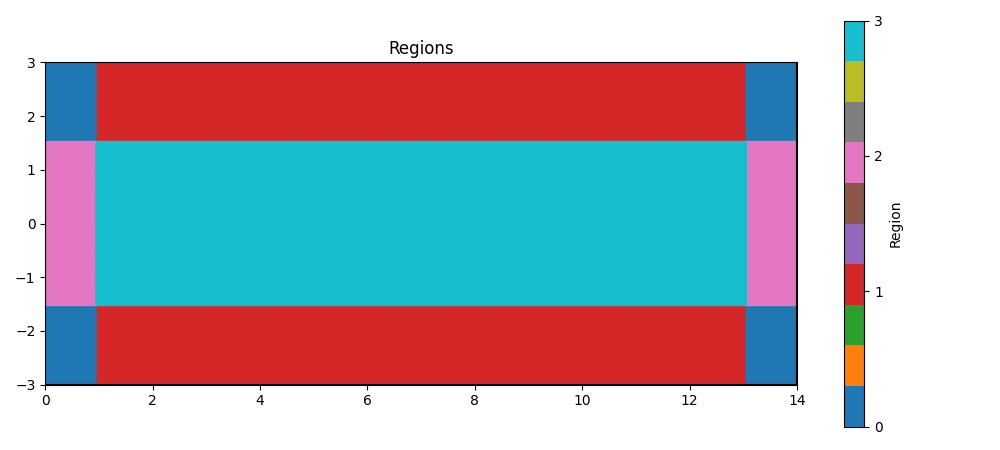

In [15]:

fig, axis = plt.subplots(1, 1, figsize=(10, 4.5), squeeze=False, sharex=True, sharey=True)

sc = axis[0,0].scatter(particles.positions[:, 0].cpu(), particles.positions[:, 1].cpu(), c = setIndex.cpu(), marker = '.', cmap = 'tab10')
fig.colorbar(sc, ax=axis[0,0], ticks=[0, 1, 2, 3], label='Region')
# axis[0,0].scatter(particlesB.positions[:, 0].cpu(), particlesB.positions[:, 1].cpu(), s = 4, marker = '.')
# axis[0,0].scatter(particlesC.positions[:, 0].cpu(), particlesC.positions[:, 1].cpu(), s = 4, marker = '.')
# axis[0,0].scatter(particlesD.positions[:, 0].cpu(), particlesD.positions[:, 1].cpu(), s = 4, marker = '.')

axis[0,0].set_title('Regions')

plotDomain(axis[0,0], domain)

fig.tight_layout()

In [5]:

# config.domain.min[0] = -L/2/aspect
# config.domain.max[0] = L/2/aspect
# config.domain.min[1] = 0 - 2*band * dx
# config.domain.max[1] = L + 2*band * dx

density = warpOperation(
    compressibleSystem.state, 
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Density,
        supportMode = SupportScheme.Gather,
        gradientMode = config.gradientMode,
        laplacianMode = config.laplacianMode,
    ),
    domain = config.domain,
)

print(f"Density: Min: {density.min().item()}, Max: {density.max().item()}, Mean: {density.mean().item()}")

Density: Min: 0.12513954937458038, Max: 1.0029754638671875, Mean: 0.9246436953544617


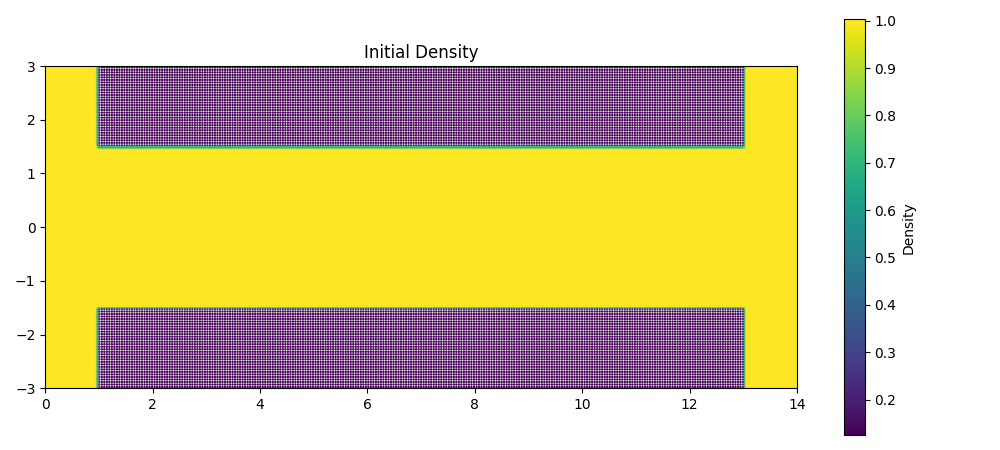

In [6]:
fig, axis = plt.subplots(1, 1, figsize=(10, 4.5), squeeze=False, sharex=True, sharey=True)
scatter = axis[0,0].scatter(compressibleSystem.state.positions[:, 0].cpu(), compressibleSystem.state.positions[:, 1].cpu(), c = density.cpu(), s = 0.5)
fig.colorbar(scatter, ax=axis[0,0], label='Density')
axis[0,0].set_title('Initial Density')

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(config.domain.min[0].cpu(), config.domain.max[0].cpu())
    ax.set_ylim(config.domain.min[1].cpu(), config.domain.max[1].cpu())

fig.tight_layout()

In [18]:
particles = compressibleSystem.state

rhoInitial = particles.densities.clone()
Pi = particles.pressures.clone()

regionI = torch.logical_or(particles.positions[:,0] <= 1.0, particles.positions[:,0] >= 13)
regionII = torch.logical_and(~regionI, particles.positions[:,1].abs() >= 1.5)
regionIII = torch.logical_and(~regionI, particles.positions[:,1].abs() < 1.5)

rhoInitial[regionI] = rho_I
Pi[regionI] = p_I
rhoInitial[regionII] = rho_II
Pi[regionII] = p_II
rhoInitial[regionIII] = rho_III
Pi[regionIII] = p_III

densityRatio = 1 # equal mass sampling, so we don't need to adjust the masses 
# densityRatio = rhoInitial / particles.densities # for equal spacing sampling, we need to adjust the masses to achieve the target density


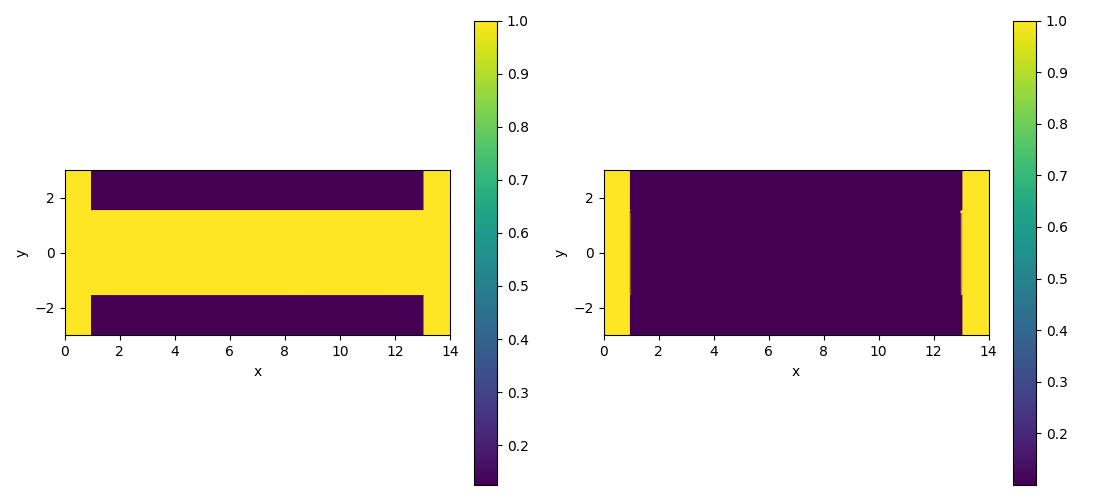

In [19]:
fig, axis = plt.subplots(1, 2, figsize=(11,5), squeeze=False)

sc = axis[0,0].scatter(particles.positions[:,0].cpu(), particles.positions[:,1].cpu(), c = rhoInitial.cpu(), s = 1, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,0])

sc = axis[0,1].scatter(particles.positions[:,0].cpu(), particles.positions[:,1].cpu(), c = Pi.cpu(), s = 1, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,1])

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(config.domain.min[0].item(), config.domain.max[0].item())
    ax.set_ylim(config.domain.min[1].item(), config.domain.max[1].item())
    ax.set_xlabel('x')
    ax.set_ylabel('y')

fig.tight_layout()

In [20]:
Lx = config.domain.max[0] - config.domain.min[0]
Ly = config.domain.max[1] - config.domain.min[1]
aspect = Ly / Lx

dx = Lx / (nx / aspect)
dy = Ly / nx

area = Lx * Ly / nx**2 * aspect


In [21]:
# Pinitial = Pi
# rhoInitial = rho_y


A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = Pi, rho = rhoInitial, gamma = gamma)
# v_initial = torch.zeros_like(particles_l.positions)

vInitial = torch.zeros_like(particles.positions)
internalEnergy = u_ 
kineticEnergy = torch.linalg.norm(vInitial, dim = -1) **2/ 2
totalEnergy = (internalEnergy + kineticEnergy) * particles.masses

particles.internalEnergies = u_
particles.totalEnergies = totalEnergy
particles.pressures = P_
particles.soundspeeds = c_s
particles.velocities = vInitial
particles.densities = rhoInitial
# particles.masses = area * rhoInitial

compressibleSystem = SimulationSystem(
    state=particles, 
    adjacency = adjacency, 
    domain = config.domain)

In [22]:

# rho_optimal, h_optimal, adjacency, rhos_iter, supports_iter = evaluateOptimalSupport(particles, config, supportScheme = SupportScheme.Gather, compParams = compressibleSPHConfig)

# compressibleSystem.state.supports = h_optimal


In [23]:

adjacency = buildVerletList(
    compressibleSystem.state, 
    config.domain, verletScale = 1.0, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = None,
    verbose = False)

apparentVolume, compressibleSystem.state.densities, crkState = computeCRKFactors(compressibleSystem.state, config.domain, config.kernel, adjacency = adjacency)

Module sphWarpCore.crk.crk_volume 793e787 load on device 'cuda:0' took 31.12 ms  (cached)
Module sphWarpCore.crk.crk_moments 89bc989 load on device 'cuda:0' took 11.46 ms  (cached)
Module sphWarpCore.crk.crk_density 06a7669 load on device 'cuda:0' took 6.71 ms  (cached)


In [24]:
enforceDirichlet(compressibleSystem.state, compressibleSystem.t, config.dt, config, compressibleSPHConfig)

In [30]:
from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, DivergingColorMap, Mapping
markerSize = 12.5
plotter = visualize(
    particleState = compressibleSystem.state,
    domain = config.domain,
    quantities = {
        "A": compressibleSystem.state.densities,
        "B": h_optimal,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "Densities",
            # mapping = Mapping.L2,
            # plottingOperation = OperationProperties(
            #     kernel = config.kernel,
            #     operation = WarpOperation.Curl,
            #     supportMode = SupportScheme.Gather,
            #     gradientMode = config.gradientMode,
            # ),
            # gridVisualization = GridVisualization(
            #     resolution = 256,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap = True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "Support Radius",
            # gridVisualization = GridVisualization(
            #     resolution = 1024,
            # ),
            # vMin=0.95,
            # vMax=2.05
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (8,7),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

# if args.exportImages:
#     plotter.export(f'output/{folderName}/frame_00000.png', dpi = args.figureDpi)

RFBOutputContext()

In [31]:
from warpPlot import *

In [32]:
KE = (compressibleSystem.state.masses * torch.linalg.norm(compressibleSystem.state.velocities, dim = -1)**2 / 2).sum()
IE = (compressibleSystem.state.masses * compressibleSystem.state.internalEnergies).sum()
TE = (compressibleSystem.state.masses * (compressibleSystem.state.internalEnergies + torch.linalg.norm(compressibleSystem.state.velocities, dim = -1)**
2)).sum()
print(f"Initial KE: {KE}, IE: {IE}, TE: {TE}, TE+PE: {TE}")

nonzeroEnergyMask = compressibleSystem.state.internalEnergies > 1e-8
print(f"Nonzero internal energy particles: {nonzeroEnergyMask.sum()} / {compressibleSystem.state.internalEnergies.shape[0]}")

Initial KE: 0.0, IE: 47.70599365234375, TE: 47.70599365234375, TE+PE: 47.70599365234375
Nonzero internal energy particles: 190869 / 190869


In [33]:
from compressibleSPH.schemes.compSPH import compSPH_step
from compressibleSPH.modules.timestep.compressible import computeTimestep
config.dt = computeTimestep(compressibleSystem, config, compressibleSPHConfig, dt = config.dt) * 2/3
print(f"Initial timestep: {config.dt}")

Initial timestep: 0.0007333333293596903


In [34]:
runningState = compressibleSystem.initializeNewState()

In [35]:
compressibleSPHConfig.adaptiveSupportScheme = AdaptiveSupportScheme.Owen
# compressibleSPHConfig.viscositySwitchParams.scheme = ViscositySwitch.CullenHopkins
# schemeConfig.diffusionParams.C_q = 1.0



In [ ]:
from compressibleSPH.io import *

exportPath = prepExport('triplePoint', config, compressibleSPHConfig, scheme, export_fn)

exportSimulationSystem(exportPath, 'initialState', scheme, runningState, exportAdjacency = False, stages = None, exportStagesAdjacency = True)

In [48]:
from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, DivergingColorMap, Mapping, CyclicColorMap
markerSize = 1
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.densities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap = True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Logarithmic,
            plotTitle = "density",
            gridVisualization = GridVisualization(
                resolution = 1024,
            ),
            vMin=0.2,
            vMax=7
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'A',
    figsize= (12,6),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

# if args.exportImages:

RFBOutputContext()

In [49]:
folderName = f"triple_{getCurrentTimestamp()}"
os.makedirs(f'output/{folderName}', exist_ok = True)
plotter.export(f'output/{folderName}/frame_00000.png', dpi = 200)

In [50]:
t_limit = 1.0
# config.dt = 1e-4
nSteps = int(t_limit / config.dt)
integrator = getIntegrator(config.integrationScheme)


print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
# nSteps = 54
print(nSteps//25)

Running with dt: 0.00025, which gives nSteps: 4000
160


In [ ]:
# os.makedirs('images/kevinHH_256_2', exist_ok = True)

t_limit = 10.0
# t_limit = 0.1
# config.dt = 1e-4
config.minDt = 1e-8
config.maxDt = 1e-3
config.dt = 2.5e-4
nSteps = int(t_limit / config.dt)
integrator = getIntegrator(config.integrationScheme)

print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
# nSteps = 54
 
trajectory = []
runningState = compressibleSystem.initializeNewState()
priorStep = None
t = 0
i = 0
tq = tqdm(total = 1000, leave = True)

Running with dt: 0.00025, which gives nSteps: 28000


  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:

while t < t_limit:
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    # print(f"Step {i+1}/{nSteps}, time: {runningState.t:.4f}")
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,
        config = config,
        compParams = compressibleSPHConfig,
        verbose = False,
        priorStep = priorStep
    )
    end.record()
    torch.cuda.synchronize()
    elapsed_time_ms = begin.elapsed_time(end)
    t = result.state.t.item() if isinstance(result.state.t, torch.Tensor) else result.state.t
    tq.n = int(t / t_limit * 1000)
    i = i + 1

    densityRatio = runningState.state.densities / result.state.state.densities
    
    # if (densityRatio < 0.7).any() or (densityRatio > 1.5).any():
    #     print(f"Warning: Density ratio out of bounds at step {i}, min: {densityRatio.min().item()}, max: {densityRatio.max().item()}")
    #     break

    runningState = result.state
    priorStep = result.stages[-1]
    # config.dt = computeTimestep(runningState, config, compressibleSPHConfig, dt = config.dt) 


    kineticEnergy_ = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
    thermalEnergy_ = (runningState.state.internalEnergies * runningState.state.masses).sum()
    totalEnergy = kineticEnergy_ + thermalEnergy_

    tq.set_description(f"{i:6d}: time: {t:8.4g}/{t_limit:8.4g}, TE: {totalEnergy:.3g}, KE: {kineticEnergy_.cpu().item():.3g}, IE: {thermalEnergy_.cpu().item():.3g}, step time: {elapsed_time_ms:.3f}ms, adaptive dt: {config.dt:.3g}")
    
        
    trajectory.append((
        i,
        runningState.t,
        elapsed_time_ms,
        kineticEnergy_.cpu().item(),
        thermalEnergy_.cpu().item(),
        totalEnergy.cpu().item(),
    ))
    if (i % 10 == 0 and i > 0) or i == nSteps - 1:
        plotter.updateQuantities(
            {
                # "A": runningState.state.velocities,
                "A": runningState.state.densities,
            },
            newParticleState = runningState.state,
        )
        plotter.export(f'output/{folderName}/frame_{i:05d}.png', dpi = 300)
        # for ax in axis.flatten():
        #     ax.clear()
        # plotSod_(fig, axis, runningState.state, config, schemeConfig, config.domain, gamma, leftState, rightState, plotReference = True, plotLabels = False, scatter = True, t_ = runningState.t)
        # fig.canvas.draw()
        # fig.canvas.flush_events()
    # print(f' Supports: Min: {runningState.state.supports.min().item()}, Max: {runningState.state.supports.max().item()}, Mean: {runningState.state.supports.mean().item()}')
    
    if i % 1000 == 0:
        exportSimulationSystem(exportPath, f'state_{i:05d}', scheme, runningState, exportAdjacency = False, stages = None, exportStagesAdjacency = True)
    # break

In [ ]:

exportSimulationSystem(exportPath, 'initialState', scheme, runningState, exportAdjacency = False, stages = result.stages, exportStagesAdjacency = True)

In [ ]:
result = integrator.function(
    state = runningState,
    f = fn,
    dt = config.dt,
    config = config,
    compParams = compressibleSPHConfig,
    verbose = False,
    priorStep = priorStep
)

densityRatio = runningState.state.densities / result.state.state.densities

if (densityRatio < 0.7).any() or (densityRatio > 1.5).any():
    print(f"Warning: Density ratio out of bounds at step {i}, min: {densityRatio.min().item()}, max: {densityRatio.max().item()}")

print(runningState.state.densities.max(), runningState.state.densities.min())
print(result.state.state.densities.max(), result.state.state.densities.min())

In [ ]:
from integrators.euler import updateStateEuler

halfState = runningState.initializeNewState()
halfState = updateStateEuler(halfState, priorStep.update, config.dt * 0.5, False)

In [ ]:
# halfState.adjacency = None

In [ ]:
config.verletScale

In [ ]:
stepResult = fn(halfState, config.dt * 0.5, config, compressibleSPHConfig)

In [ ]:
nnrsPrev = runningState.adjacency.numNeighbors
print(f'Number of neighbors: min {nnrsPrev.min().item()}, max {nnrsPrev.max().item()}, mean {nnrsPrev.to(torch.float32).mean().item()}')
nnrsCurr = stepResult[1].numNeighbors
print(f'Number of neighbors: min {nnrsCurr.min().item()}, max {nnrsCurr.max().item()}, mean {nnrsCurr.to(torch.float32).mean().item()}')

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(11,10), squeeze=False)
sc = axis[0,0].scatter(runningState.state.positions[:,0].cpu(), runningState.state.positions[:,1].cpu(), c = nnrsPrev.cpu(), s = 1, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,0])
sc = axis[0,1].scatter(stepResult[2].positions[:,0].cpu(), stepResult[2].positions[:,1].cpu(), c = nnrsCurr.cpu(), s = 1, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,1])
for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(config.domain.min[0].item(), config.domain.max[0].item())
    ax.set_ylim(config.domain.min[1].item(), config.domain.max[1].item())
    ax.set_xlabel('x')
    ax.set_ylabel('y')
fig.tight_layout()

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(11,10), squeeze=False)
sc = axis[0,0].scatter(runningState.state.positions[:,0].cpu(), runningState.state.positions[:,1].cpu(), c = runningState.state.densities.cpu(), s = 1, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,0])
sc = axis[0,1].scatter(stepResult[2].positions[:,0].cpu(), stepResult[2].positions[:,1].cpu(), c = stepResult[2].densities.cpu(), s = 1, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,1])
for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(config.domain.min[0].item(), config.domain.max[0].item())
    ax.set_ylim(config.domain.min[1].item(), config.domain.max[1].item())
    ax.set_xlabel('x')
    ax.set_ylabel('y')
fig.tight_layout()

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(11,10), squeeze=False)
sc = axis[0,0].scatter(runningState.state.positions[:,0].cpu(), runningState.state.positions[:,1].cpu(), c = runningState.state.supports.cpu(), s = 1, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,0])
sc = axis[0,1].scatter(stepResult[2].positions[:,0].cpu(), stepResult[2].positions[:,1].cpu(), c = stepResult[2].supports.cpu(), s = 1, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,1])
for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(config.domain.min[0].item(), config.domain.max[0].item())
    ax.set_ylim(config.domain.min[1].item(), config.domain.max[1].item())
    ax.set_xlabel('x')
    ax.set_ylabel('y')
fig.tight_layout()

In [ ]:
import copy
queryPositions = halfState.state.positions
referencePositions = halfState.state.positions
querySupports = halfState.state.supports
referenceSupports = halfState.state.supports
domain = copy.deepcopy(config.domain)
domain.min = domain.min
domain.max = domain.max

verletScale = 1.0
mode = SupportScheme.Scatter

adjacency, hmap = radiusSearchCompactHashMap_(
    queryPositions, referencePositions,
    querySupports * verletScale, referenceSupports * verletScale,
    domain.periodic, domain, mode, hashMapLength=queryPositions.shape[0] + 1, returnCompactHashMap = True
)

print(adjacency.numNeighbors.min(), adjacency.numNeighbors.max(), adjacency.numNeighbors.to(torch.float).mean())

In [ ]:

print(torch.sum(adjacency.i == adjacency.j), queryPositions.shape[0])

In [ ]:
print(hmap.hashTable)
print(hmap.sortedCellTable.shape)

In [ ]:

queryPositions = halfState.state.positions.to(torch.float64)
referencePositions = halfState.state.positions.to(torch.float64)
querySupports = halfState.state.supports.to(torch.float64)
referenceSupports = halfState.state.supports.to(torch.float64)
domain = copy.deepcopy(config.domain)
domain.min = domain.min.to(torch.float64)
domain.max = domain.max.to(torch.float64)

In [ ]:
domainDescription = config.domain
periodicity = domainDescription.periodic

mode_uint = supportSchemeToUint(mode)
# mode_map = {'gather': 1, 'scatter': 2, 'symmetric': 3, 'superSymmetric': 4, ''}
# mode_uint = mode_map.get(mode, 0)
# if mode_uint == 0:
    # raise ValueError(f"Invalid mode: {mode}. Supported modes are: {list(mode_map.keys())}")
    
minDomain = domainDescription.min if domainDescription.min is not None else None
maxDomain = domainDescription.max if domainDescription.max is not None else None
hMax = computeGridSupport(querySupports, referenceSupports, mode)
minD, maxD = getDomainExtents(referencePositions, minDomain, maxDomain)
x = torch.vstack([component if not periodic else torch.remainder(component - minD[i], maxD[i] - minD[i]) + minD[i] for i, (component, periodic) in enumerate(zip(referencePositions.mT, periodicity))]).mT
y = torch.vstack([component if not periodic else torch.remainder(component - minD[i], maxD[i] - minD[i]) + minD[i] for i, (component, periodic) in enumerate(zip(queryPositions.mT, periodicity))]).mT

sortedLinear, sortIndex, numCells, qMin, qMax, hCell = sortReferenceParticles(x, hMax, minD, maxD)


sortedPositions = x[sortIndex,:]

cellIndices, cellCounters = torch.unique_consecutive(sortedLinear, return_counts=True, return_inverse=False)
cellCounters = cellCounters.to(torch.int32)
# Needs to zero padded for the indexing to work properly as the 0th cell is valid and cumsum doesn't include the first element

cumCell = torch.hstack((torch.tensor([0], device = cellIndices.device, dtype=cellCounters.dtype),torch.cumsum(cellCounters,dim=0)))[:-1].to(torch.int32)

sortedIndices = torch.floor((sortedPositions - qMin) / to_numpy(hCell)).to(torch.int32)
for d in range(sortedIndices.shape[1]):
    sortedIndices[:, d] = torch.clamp(sortedIndices[:, d], 0, int(numCells[d].item()) - 1)
cellGridIndices = sortedIndices[cumCell,:]
cellTable = torch.stack((cellIndices, cumCell, cellCounters), dim = 1)

warpDevice = castTorchToWarp(queryPositions).device
torchDevice = queryPositions.device

cellGridIndices_warp = castTorchToWarp(cellGridIndices)
hashedIndices_warp = wp.zeros(sortedIndices.shape[0], dtype=wp.uint32, device=warpDevice)
wp.launch(hashCells, dim=sortedIndices.shape[0], inputs=[sortedIndices, wp.uint32(2), hashedIndices_warp], device=warpDevice)
hashedIndices = wp.to_torch(hashedIndices_warp).to(torch.int32)

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(11,10), squeeze=False)

q = sortedLinear
qUnique = torch.unique(q)
colors = torch.rand((qUnique.shape[0], 3), device = queryPositions.device)
c = colors[torch.searchsorted(qUnique, q)]

s = 1

sc = axis[0,0].scatter(sortedPositions[:,0].cpu(), sortedPositions[:,1].cpu(), c = c.cpu(), s = s, cmap = 'viridis')
# fig.colorbar(sc, ax = axis[0,0])

q = hashedIndices
qUnique = torch.unique(q)
colors = torch.rand((qUnique.shape[0], 3), device = queryPositions.device)
c = colors[torch.searchsorted(qUnique, q)]

sc = axis[0,1].scatter(sortedPositions[:,0].cpu(), sortedPositions[:,1].cpu(), c = c.cpu(), s = s, cmap = 'viridis')
# fig.colorbar(sc, ax = axis[0,1])
for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(config.domain.min[0].item(), config.domain.max[0].item())
    ax.set_ylim(config.domain.min[1].item(), config.domain.max[1].item())
    ax.set_xlabel('x')
    ax.set_ylabel('y')

In [ ]:
ffmpeg -framerate 50 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4
ffmpeg -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png
ffmpeg -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif

In [ ]:
cState = runningState.initializeNewState()
currentState = cState.state


adjacency = buildVerletList(
    currentState, 
    config.domain, verletScale = 1.0, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = None,
    verbose = False)

apparentVolume, currentState.densities, crkState = computeCRKFactors(currentState, config.domain, config.kernel, adjacency = adjacency)


In [ ]:
def limiterVL(x):
    # if x <= 0.0:
        # return 0.0
    # x = wp.min(x, scalar_t(1.0e6))
    # vL = 2.0 / (1.0 + x)
    # return x * vL*vL

    return (x + torch.abs(x)) / (1.0 + torch.abs(x))

xx = torch.linspace(0, 1, 1000)
yy = limiterVL(xx)

fig, ax = plt.subplots()
ax.plot(xx.cpu(), yy.cpu())
ax.set_title("Van Leer Limiter")
ax.set_xlabel("x")
ax.set_ylabel("limiterVL(x)")
plt.grid()


In [ ]:
velocityGradient = warpOperation(
    currentState,
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Gradient,
        supportMode = SupportScheme.Scatter, # E.3
        gradientMode = GradientScheme.Difference, # E.3
    ),
    queryValues = currentState.velocities,
    domain = config.domain,
    adjacency = adjacency,
    # queryVolumes = apparentVolume,
    # crkState= crkState,
)

velocityGradientCRK = warpOperation(
    currentState,
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Gradient,
        supportMode = SupportScheme.Scatter, # E.3
        gradientMode = GradientScheme.Difference, # E.3
    ),
    queryValues = currentState.velocities,
    domain = config.domain,
    adjacency = adjacency,
    queryVolumes = apparentVolume,
    crkState= crkState,
)

In [ ]:
trace = torch.einsum('...ii', velocityGradient)

traces = torch.eye(velocityGradient.shape[1], device=velocityGradient.device) * trace.view(-1, 1, 1) / velocityGradient.shape[1]

Shear = (velocityGradient + velocityGradient.transpose(1,2))/2 - traces
Rotation = (velocityGradient - velocityGradient.transpose(1,2)) / 2

In [ ]:
matrix = velocityGradient# - velocityGradientCRK
from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, DivergingColorMap, Mapping
markerSize = 2
plotter = visualize(
    particleState = currentState,
    domain = config.domain,
    quantities = {
        "A": matrix[:,0,0],
        "B": matrix[:,0,1],
        "C": matrix[:,1,0],
        "D": matrix[:,1,1],
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
        ),
        "B": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
        ),
        "C": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
        ),
        "D": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = '''AB
    CD''',
    figsize= (11,10),
    # backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

# if args.exportImages:
#     plotter.export(f'output/{folderName}/frame_00000.png', dpi = args.figureDpi)

In [ ]:
display(plotter.fig)